In [2]:
print("done")

done


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns

# Base directory where the dataset is mounted
base_dir = "/kaggle/input/sicapv2"

# Check directory structure
for root, dirs, files in os.walk(base_dir):
    print(f"{root} -> {len(files)} files")


/kaggle/input/sicapv2 -> 0 files
/kaggle/input/sicapv2/SICAPv2 -> 0 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2 -> 2 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/images -> 18783 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition -> 0 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation -> 0 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation/Val3 -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation/Val4 -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation/Val2 -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Validation/Val1 -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/partition/Test -> 4 files
/kaggle/input/sicapv2/SICAPv2/SICAPv2/masks -> 18783 files


In [4]:
import os

image_dir = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/images"
print("Files in images dir:", os.listdir(image_dir)[:5])


Files in images dir: ['16B0006669_Block_Region_24_6_2_xini_14275_yini_13598.jpg', '18B0005230E_Block_Region_5_11_23_xini_38257_yini_96363.jpg', '18B0006621D_Block_Region_2_1_13_xini_21582_yini_66086.jpg', '18B0006177A_Block_Region_2_6_19_xini_51693_yini_147491.jpg', '16B0022612_Block_Region_1_20_12_xini_15667_yini_92428.jpg']


Total images found: 18783
✅ Found matching image + mask for: 18B0005478J_Block_Region_15_0_1_xini_41757_yini_1892.jpg
Image shape: (512, 512, 3)
Mask shape: (512, 512)
Unique values in mask: [0]


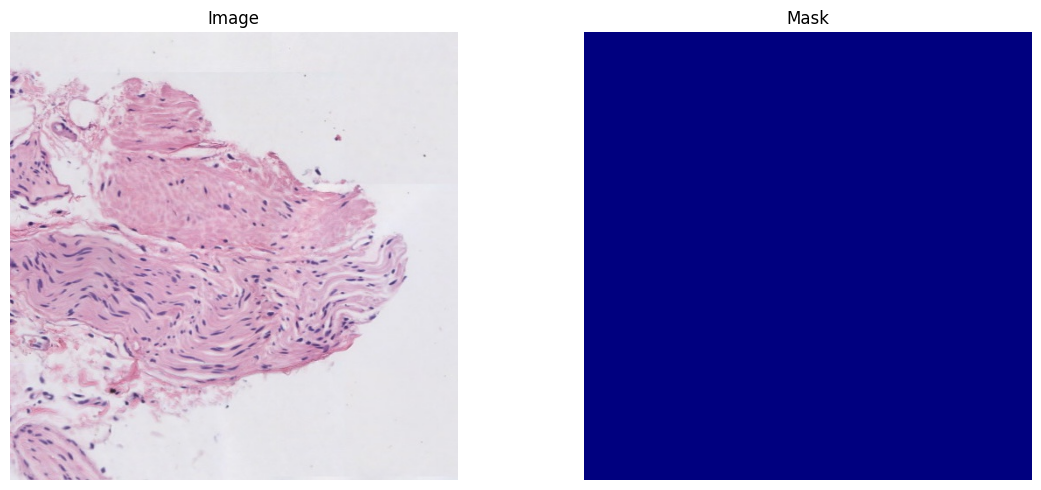

In [5]:
import random
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from glob import glob

# Correct image and mask directories
image_dir = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/images"
mask_dir = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/masks"

# Get list of image files
image_paths = glob(os.path.join(image_dir, "*.jpg"))
print(f"Total images found: {len(image_paths)}")

# Try loading image-mask pair
for _ in range(20):
    sample_image_path = random.choice(image_paths)
    filename = os.path.basename(sample_image_path)
    sample_mask_path = os.path.join(mask_dir, filename)  # No extension change now

    if os.path.exists(sample_mask_path):
        print("✅ Found matching image + mask for:", filename)
        break
else:
    raise FileNotFoundError("No matching masks found for any image.")

# Load image and mask
image = cv2.imread(sample_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

# Print some sanity info
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Unique values in mask:", np.unique(mask))

# Show image and mask
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='jet')
plt.title("Mask")
plt.axis("off")

plt.tight_layout()
plt.show()


In [6]:
import pandas as pd

# Path to Excel label file
xlsx_path = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/wsi_labels.xlsx"

# Read Excel
df = pd.read_excel(xlsx_path)

# Your GG logic
def gleason_to_gg(primary, secondary):
    total = primary + secondary
    if total == 7 and primary == 4:
        return "GG3"
    elif total == 8:
        return "GG4"
    elif total >= 9:
        return "GG5"
    else:
        return "NC"

df["GG"] = df.apply(lambda row: gleason_to_gg(row["Gleason_primary"], row["Gleason_secondary"]), axis=1)

print(df.head())
print(df["GG"].value_counts())


     slide_id  patient_id  Gleason_primary  Gleason_secondary   GG
0  16B0001851      667360                4                  5  GG5
1  16B0003388      325687                4                  4  GG4
2  16B0003394      747184                3                  3   NC
3  16B0006668       14107                5                  5  GG5
4  16B0006669       14107                5                  5  GG5
GG
NC     72
GG5    42
GG3    23
GG4    18
Name: count, dtype: int64


In [7]:
from glob import glob
import pandas as pd
import os

# Load GG labels
labels_df = pd.read_excel("/kaggle/input/sicapv2/SICAPv2/SICAPv2/wsi_labels.xlsx")
def gleason_to_gg(primary, secondary):
    total = primary + secondary
    if total == 7 and primary == 4:
        return "GG3"
    elif total == 8:
        return "GG4"
    elif total >= 9:
        return "GG5"
    else:
        return "NC"
labels_df["GG"] = labels_df.apply(lambda row: gleason_to_gg(row["Gleason_primary"], row["Gleason_secondary"]), axis=1)

# Create a dictionary for quick lookup
slideid_to_gg = dict(zip(labels_df["slide_id"].astype(str), labels_df["GG"]))

# Grab all patch image paths
patch_dir = "/kaggle/input/sicapv2/SICAPv2/SICAPv2/images"
patch_paths = glob(os.path.join(patch_dir, "*.jpg"))

# Build dataframe with patch paths and labels
patch_data = []
for path in patch_paths:
    filename = os.path.basename(path)
    slide_id = filename.split("_")[0]
    if slide_id in slideid_to_gg:
        label = slideid_to_gg[slide_id]
        patch_data.append((path, label))

# Create final dataframe
patch_df = pd.DataFrame(patch_data, columns=["path", "label"])
print("Total labeled patches:", len(patch_df))
print(patch_df["label"].value_counts())
patch_df.head()


Total labeled patches: 18783
label
NC     7995
GG5    5654
GG3    3082
GG4    2052
Name: count, dtype: int64


,path,label
0,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,GG5
1,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,NC
2,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,GG3
3,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,GG5
4,/kaggle/input/sicapv2/SICAPv2/SICAPv2/images/1...,NC


In [8]:
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

label_to_idx = {"NC": 0, "GG3": 1, "GG4": 2, "GG5": 3}

class PatchDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        label_str = self.df.loc[idx, "label"]
        label = label_to_idx[label_str]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label


In [9]:
from sklearn.model_selection import train_test_split

# First split: train vs (val + test)
train_df, temp_df = train_test_split(
    patch_df, test_size=0.2, stratify=patch_df["label"], random_state=42)

# Second split: val vs test
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 15026 | Val: 1878 | Test: 1879


In [10]:
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

label_to_idx = {"NC": 0, "GG3": 1, "GG4": 2, "GG5": 3}

class PatchDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        label_str = self.df.loc[idx, "label"]
        label = label_to_idx[label_str]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label


In [11]:
# ---------------- Imports ----------------
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import densenet169, DenseNet169_Weights
from torchvision.models import swin_t, Swin_T_Weights
from PIL import Image
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm


In [12]:
# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------- DenseNet-169 ----------------
densenet_weights = DenseNet169_Weights.DEFAULT
densenet = densenet169(weights=densenet_weights)

# Remove the classifier
densenet_features = nn.Sequential(*list(densenet.children())[:-1])  # keep everything except last fc
densenet_features.to(device)
print("✅ DenseNet-169 loaded, classifier removed")

# ---------------- Swin Transformer ----------------
swin_weights = Swin_T_Weights.DEFAULT
swin = swin_t(weights=swin_weights)

# Remove the classifier
swin_features = nn.Sequential(*list(swin.children())[:-1])  # keep everything except last head
swin_features.to(device)
print("✅ Swin-T loaded, classifier removed")


Using device: cuda


Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth
100%|██████████| 54.7M/54.7M [00:00<00:00, 160MB/s] 


✅ DenseNet-169 loaded, classifier removed


Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth
100%|██████████| 108M/108M [00:00<00:00, 213MB/s] 


✅ Swin-T loaded, classifier removed


# 🔹 Load Pretrained DenseNet-169 and Swin Transformer
We are loading DenseNet-169 and Swin-T with pretrained weights, removing their classification heads, and keeping only the feature extraction parts. This will allow us to fuse their features for a custom classifier.


In [13]:
# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------- DenseNet-169 ----------------
from torchvision.models import densenet169, DenseNet169_Weights
import torch.nn as nn

densenet_weights = DenseNet169_Weights.DEFAULT
densenet = densenet169(weights=densenet_weights)

# Remove the classifier
densenet_features = nn.Sequential(*list(densenet.children())[:-1])  # keep everything except last fc
densenet_features.to(device)
print("✅ DenseNet-169 loaded, classifier removed")

# ---------------- Swin Transformer ----------------
from torchvision.models import swin_t, Swin_T_Weights

swin_weights = Swin_T_Weights.DEFAULT
swin = swin_t(weights=swin_weights)

# Remove the classifier
swin_features = nn.Sequential(*list(swin.children())[:-1])  # keep everything except last head
swin_features.to(device)
print("✅ Swin-T loaded, classifier removed")


Using device: cuda
✅ DenseNet-169 loaded, classifier removed
✅ Swin-T loaded, classifier removed


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DenseNetSwinFusion(nn.Module):
    def __init__(self, densenet_model, swin_model, num_classes=4):
        super(DenseNetSwinFusion, self).__init__()
        self.densenet = densenet_model
        self.swin = swin_model

        # Compute output feature sizes dynamically with dummy input
        with torch.no_grad():
            dummy = torch.randn(1, 3, 224, 224).to(device)  # Swin expects 224x224
            densenet_out = self.densenet(dummy)
            swin_out = self.swin(dummy)

            self.densenet_feat_dim = densenet_out.flatten(1).shape[1]
            self.swin_feat_dim = swin_out.flatten(1).shape[1]

        # Fusion classifier
        self.classifier = nn.Linear(self.densenet_feat_dim + self.swin_feat_dim, num_classes)

    def forward(self, x):
        d_feat = self.densenet(x)
        s_feat = self.swin(x)

        # Flatten
        d_feat = d_feat.flatten(1)
        s_feat = s_feat.flatten(1)

        # Concatenate features
        fused = torch.cat([d_feat, s_feat], dim=1)

        # Classifier
        out = self.classifier(fused)
        return out

# ---------------- Instantiate fusion model ----------------
num_classes = 4  # NC, GG3, GG4, GG5
fusion_model = DenseNetSwinFusion(densenet_features, swin_features, num_classes=num_classes)
fusion_model.to(device)
print("✅ Fusion model ready, features unfrozen and classifier added")


✅ Fusion model ready, features unfrozen and classifier added


In [15]:
from torchvision import transforms
from torch.utils.data import DataLoader

# ---------------- Data augmentation ----------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ---------------- Datasets ----------------
train_dataset_obj = PatchDataset(train_df, transform=train_transform)
val_dataset_obj = PatchDataset(val_df, transform=val_test_transform)
test_dataset_obj = PatchDataset(test_df, transform=val_test_transform)

# ---------------- Dataloaders ----------------
batch_size = 32

train_loader = DataLoader(train_dataset_obj, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset_obj, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset_obj, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ DataLoaders ready | Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")


✅ DataLoaders ready | Train: 470, Val: 59, Test: 59


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------------- AFA Module ----------------
class AFAModule(nn.Module):
    def __init__(self, feature_dim1, feature_dim2, reduction=16):
        super(AFAModule, self).__init__()
        self.fc1 = nn.Linear(feature_dim1, feature_dim1 // reduction)
        self.fc2 = nn.Linear(feature_dim2, feature_dim2 // reduction)
        self.fc3 = nn.Linear(feature_dim1 // reduction + feature_dim2 // reduction, feature_dim1 + feature_dim2)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x1, x2):
        # x1: features from DenseNet, x2: features from Swin
        y1 = F.relu(self.fc1(x1))
        y2 = F.relu(self.fc2(x2))
        y = torch.cat([y1, y2], dim=1)
        attention = self.sigmoid(self.fc3(y))
        fused = x1 * attention[:, :x1.size(1)] + x2 * attention[:, x1.size(1):]
        return fused

# ---------------- Fusion Model ----------------
class AFAModuleFusion(nn.Module):
    def __init__(self, densenet, swin, num_classes=4):
        super(AFAModuleFusion, self).__init__()
        self.densenet = densenet
        self.swin = swin
        
        # Freeze classifier layers removed, features unfrozen
        self.densenet_fc_in = densenet.classifier.in_features
        self.swin_fc_in = swin.head.in_features
        
        self.afa = AFAModule(self.densenet_fc_in, self.swin_fc_in)
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),  # GAP if needed
            nn.Flatten(),
            nn.Linear(self.densenet_fc_in + self.swin_fc_in, num_classes)
        )
    
    def forward(self, x):
        feat1 = self.densenet.features(x)
        feat1 = F.relu(feat1, inplace=True)
        feat1 = F.adaptive_avg_pool2d(feat1, (1,1)).view(feat1.size(0), -1)
        
        feat2 = self.swin(x)  # get features from swin (already removed head)
        if isinstance(feat2, tuple):
            feat2 = feat2[0]  # for some swin implementations
        
        fused = self.afa(feat1, feat2)
        
        out = self.classifier(fused.unsqueeze(-1))  # GAP expects 3D for AdaptiveAvgPool1d
        return out


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AFAModuleFusion(nn.Module):
    def __init__(self, densenet, swin, densenet_in, swin_in, num_classes=4):
        super().__init__()
        self.densenet = densenet
        self.swin = swin

        # AFA: simple attention fusion (example)
        fused_dim = densenet_in + swin_in
        self.attention = nn.Sequential(
            nn.Linear(fused_dim, fused_dim // 2),
            nn.ReLU(),
            nn.Linear(fused_dim // 2, fused_dim),
            nn.Sigmoid()
        )

        # final classifier
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, fused_dim // 2),
            nn.ReLU(),
            nn.Linear(fused_dim // 2, num_classes)
        )

    def forward(self, x):
        f1 = self.densenet(x)
        f2 = self.swin(x)
        fused = torch.cat([f1, f2], dim=1)

        attn = self.attention(fused)
        fused = fused * attn  # element-wise attention

        out = self.classifier(fused)
        return out


In [18]:
# ---------------- Instantiate model ----------------
from torchvision.models import densenet169
from timm import create_model

# DenseNet
densenet = densenet169(weights='IMAGENET1K_V1')
densenet_fc_in = densenet.classifier.in_features  # save before removing
densenet.classifier = nn.Identity()  # remove classifier

# Swin-Tiny
from timm import create_model
swin = create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=1000)  # temporary head
swin_fc_in = swin.head.in_features  # save in_features
swin.head = nn.Identity()  # remove classifier

# Fusion model
model = AFAModuleFusion(densenet, swin, densenet_fc_in, swin_fc_in, num_classes=4)
model = model.to(device)


print("✅ Fusion model ready, features unfrozen and classifier added")


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

✅ Fusion model ready, features unfrozen and classifier added


In [19]:
import torch.optim as optim
import torch.nn as nn

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Using device:", device)

# ---------------- Optimizer ----------------
optimizer = optim.Adam([
    {'params': model.densenet.parameters(), 'lr': 1e-5},
    {'params': model.swin.parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-4},
    {'params': model.attention.parameters(), 'lr': 1e-4}
], weight_decay=1e-5)

# ---------------- Loss ----------------
criterion = nn.CrossEntropyLoss()

# ---------------- Scheduler ----------------
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)  # adjust T_max for total epochs

# ---------------- Checkpoint directory ----------------
ckpt_dir = "./fusion_checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)
best_val_acc = 0.0

print("✅ Optimizer, criterion, scheduler ready")


Using device: cuda
✅ Optimizer, criterion, scheduler ready


In [20]:
def forward(self, x):
    # DenseNet features
    f1 = self.densenet(x)  # [B, C, 1, 1] or [B, C]
    if f1.dim() == 4:
        f1 = F.adaptive_avg_pool2d(f1, (1,1)).flatten(1)  # [B, C]
    
    # Swin features
    f2 = self.swin(x)      # [B, C, H, W] or tuple
    if isinstance(f2, tuple):
        f2 = f2[0]
    if f2.dim() == 4:
        f2 = F.adaptive_avg_pool2d(f2, (1,1)).flatten(1)  # [B, C]

    # Attention fusion
    fused = torch.cat([f1, f2], dim=1)
    attn = self.attention(fused)
    fused = fused * attn

    # Classifier
    out = self.classifier(fused)
    return out


In [21]:
batch_size = 16  # reduced from 32

train_loader = DataLoader(train_dataset_obj, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset_obj, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset_obj, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ DataLoaders ready | Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")


✅ DataLoaders ready | Train: 940, Val: 118, Test: 118


In [22]:
num_epochs = 10

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0

for epoch in range(1, num_epochs+1):
    torch.cuda.empty_cache()  # free up fragmented memory at the start
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} - Training"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # ---------------- Validation ----------------
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} - Validation"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    
    val_loss /= val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"\nEpoch {epoch}/{num_epochs} -> Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # ---------------- Scheduler step ----------------
    scheduler.step()
    
    # ---------------- Checkpoints ----------------
    # Save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(ckpt_dir, "best_fusion_model.pth"))
        print("✅ Best checkpoint saved!")
    
    # Save last epoch
    torch.save(model.state_dict(), os.path.join(ckpt_dir, "last_epoch_fusion_model.pth"))

# ---------------- Plot losses and accuracies ----------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend(); plt.title("Loss per Epoch")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend(); plt.title("Accuracy per Epoch")
plt.show()


Epoch 1/10 - Training:   0%|          | 0/940 [00:00<?, ?it/s]


RuntimeError: Tensors must have same number of dimensions: got 2 and 4

In [24]:
import torch, gc

# Clear cache & force garbage collection
torch.cuda.empty_cache()
gc.collect()

# Optional: check again
print("Allocated:", round(torch.cuda.memory_allocated(0)/1024**3,2), "GB")
print("Cached:   ", round(torch.cuda.memory_reserved(0)/1024**3,2), "GB")


Allocated: 4.31 GB
Cached:    4.49 GB


In [25]:
# Make sure nothing else is holding memory
import gc
gc.collect()
torch.cuda.empty_cache()

# Move one batch to GPU as a test
imgs, labels = next(iter(train_loader))
imgs, labels = imgs.to(device), labels.to(device)
print("Batch moved successfully!")


Batch moved successfully!


In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models
import timm
from torch.utils.data import DataLoader, Dataset
from PIL import Image

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------- Dataset ----------------
class PatchDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_to_idx = {"NC":0, "GG3":1, "GG4":2, "GG5":3}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.loc[idx, "path"]
        label_str = self.df.loc[idx, "label"]
        label = self.label_to_idx[label_str]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# ---------------- Transforms ----------------
train_transform = transforms.Compose([
    transforms.Resize((299,299)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ---------------- DataLoaders ----------------
train_dataset = PatchDataset(train_df, transform=train_transform)
val_dataset   = PatchDataset(val_df, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

# ---------------- Backbones ----------------
densenet = models.densenet121(weights="IMAGENET1K_V1")
densenet.classifier = nn.Identity()
densenet = densenet.to(device)

swin = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True)
swin.head = nn.Identity()
swin = swin.to(device)

# ---------------- Classifier ----------------
class AFAClassifier(nn.Module):
    def __init__(self, input_dim, num_classes=4):
        super().__init__()
        self.afa = nn.Sequential(
            nn.Linear(input_dim, input_dim//2),
            nn.ReLU(),
            nn.Linear(input_dim//2, input_dim),
            nn.Sigmoid()
        )
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        x = self.afa(x)
        return self.fc(x)

# ---------------- Fusion Model ----------------
class DenseSwinAFA(nn.Module):
    def __init__(self, densenet, swin, num_classes=4):
        super().__init__()
        self.densenet = densenet
        self.swin = swin

        self.pool = nn.AdaptiveAvgPool2d(1)

        # Dynamic fused dim calculation
        with torch.no_grad():
            dummy = torch.randn(1,3,299,299).to(device)
            f_densenet = self.densenet(dummy)
            if f_densenet.dim() > 2:
                f_densenet = self.pool(f_densenet)
                f_densenet = torch.flatten(f_densenet, 1)

            dummy_swin = nn.functional.interpolate(dummy, size=(224,224), mode="bilinear", align_corners=False)
            f_swin = self.swin(dummy_swin)
            if f_swin.dim() > 2:
                f_swin = self.pool(f_swin)
                f_swin = torch.flatten(f_swin, 1)

            fused_dim = f_densenet.size(1) + f_swin.size(1)

        self.classifier = AFAClassifier(fused_dim, num_classes)

    def forward(self, x):
        x = x.to(next(self.parameters()).device)

        # DenseNet features
        f_densenet = self.densenet(x)
        if f_densenet.dim() > 2:
            f_densenet = self.pool(f_densenet)
            f_densenet = torch.flatten(f_densenet, 1)

        # Swin features
        x_swin = nn.functional.interpolate(x, size=(224,224), mode="bilinear", align_corners=False)
        f_swin = self.swin(x_swin)
        if f_swin.dim() > 2:
            f_swin = self.pool(f_swin)
            f_swin = torch.flatten(f_swin, 1)

        # Concatenate + classify
        fused = torch.cat([f_densenet, f_swin], dim=1)
        return self.classifier(fused)

# ---------------- Instantiate ----------------
model = DenseSwinAFA(densenet, swin).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

print("✅ DenseNet+Swin AFA Fusion Model ready for training.")


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


Using device: cuda


100%|██████████| 30.8M/30.8M [00:00<00:00, 171MB/s]


✅ DenseNet+Swin AFA Fusion Model ready for training.


In [34]:
import torch
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

# ---------------- Hyperparameters ----------------
num_epochs = 20
best_val_acc = 0.0

# ---------------- Loss & Optimizer ----------------
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.7)  # optional
scaler = GradScaler()  # mixed precision

# ---------------- Trackers ----------------
train_losses, val_losses = [], []
train_accs, val_accs = [], []

# ---------------- Training Loop ----------------
for epoch in range(1, num_epochs+1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} - Training"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        with autocast():  # mixed precision
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # ---------------- Validation ----------------
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} - Validation"):
            imgs, labels = imgs.to(device), labels.to(device)
            with autocast():
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            
            val_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    
    val_loss /= val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"\nEpoch {epoch}/{num_epochs} -> Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    scheduler.step()
    
    # ---------------- Save Best Model ----------------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(ckpt_dir, "best_densenet_swin_model.pth"))
        print("✅ Best checkpoint saved!")

# ---------------- Plot ----------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend(); plt.title("Loss per Epoch")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend(); plt.title("Accuracy per Epoch")
plt.show()


/tmp/ipykernel_36/4187575303.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # mixed precision
Epoch 1/20 - Training:   0%|          | 0/940 [00:00<?, ?it/s]/tmp/ipykernel_36/4187575303.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # mixed precision
Epoch 1/20 - Validation:   0%|          | 0/118 [00:00<?, ?it/s]/tmp/ipykernel_36/4187575303.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/20 - Validation: 100%|██████████| 118/118 [00:11<00:00, 10.21it/s]



Epoch 1/20 -> Train Loss: 0.0791 | Train Acc: 0.9730 | Val Loss: 0.2442 | Val Acc: 0.9265
✅ Best checkpoint saved!


Epoch 2/20 - Validation: 100%|██████████| 118/118 [00:11<00:00, 10.26it/s]



Epoch 2/20 -> Train Loss: 0.0698 | Train Acc: 0.9743 | Val Loss: 0.2398 | Val Acc: 0.9223


Epoch 3/20 - Validation: 100%|██████████| 118/118 [00:11<00:00, 10.23it/s]


...


Epoch 11/20 -> Train Loss: 0.0060 | Train Acc: 0.9982 | Val Loss: 0.0903 | Val Acc: 0.9734


Epoch 12/20 - Validation: 100%|██████████| 118/118 [00:11<00:00, 10.21it/s]



Epoch 12/20 -> Train Loss: 0.0101 | Train Acc: 0.9961 | Val Loss: 0.0946 | Val Acc: 0.9723


Epoch 13/20 - Training:  10%|█         | 98/940 [00:26<03:51,  3.64it/s]


KeyboardInterrupt: 

✅ Loaded best checkpoint for testing.

Test Accuracy: 0.8712

Classification Report:
              precision    recall  f1-score   support

          NC       0.84      0.97      0.90       800
         GG3       0.92      0.65      0.76       308
         GG4       0.82      0.92      0.87       205
         GG5       0.92      0.84      0.88       566

    accuracy                           0.87      1879
   macro avg       0.88      0.84      0.85      1879
weighted avg       0.88      0.87      0.87      1879



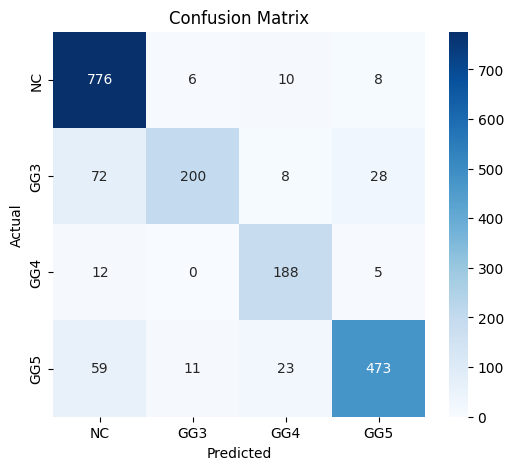

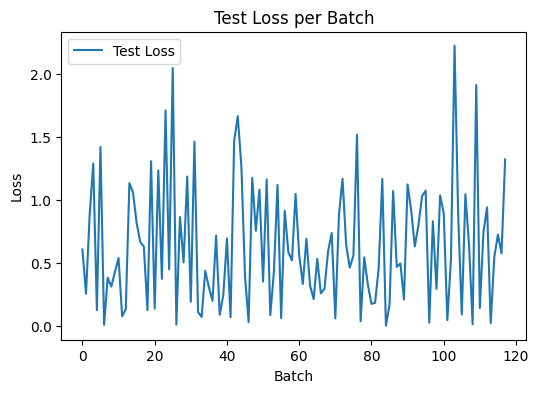

In [35]:
 import torch
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------- Load Best Model ----------------
model.load_state_dict(torch.load(os.path.join(ckpt_dir, "best_densenet_swin_model.pth")))
model.eval()
model.to(device)
print("✅ Loaded best checkpoint for testing.")

# ---------------- Test Loop ----------------
test_losses = []
test_correct, test_total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        
        test_losses.append(loss.item())
        preds = outputs.argmax(dim=1)
        
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ---------------- Metrics ----------------
test_acc = test_correct / test_total
print(f"\nTest Accuracy: {test_acc:.4f}\n")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["NC", "GG3", "GG4", "GG5"]))

# ---------------- Confusion Matrix ----------------
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["NC", "GG3", "GG4", "GG5"], yticklabels=["NC", "GG3", "GG4", "GG5"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ---------------- Test Loss Curve ----------------
plt.figure(figsize=(6,4))
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Test Loss per Batch")
plt.legend()
plt.show()


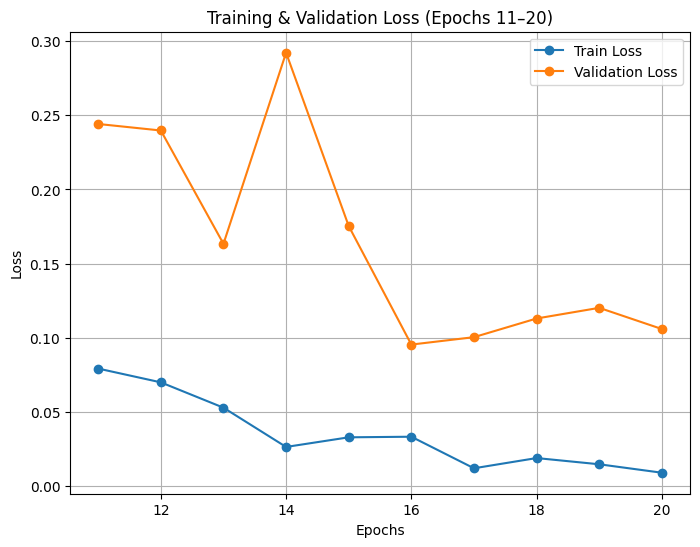

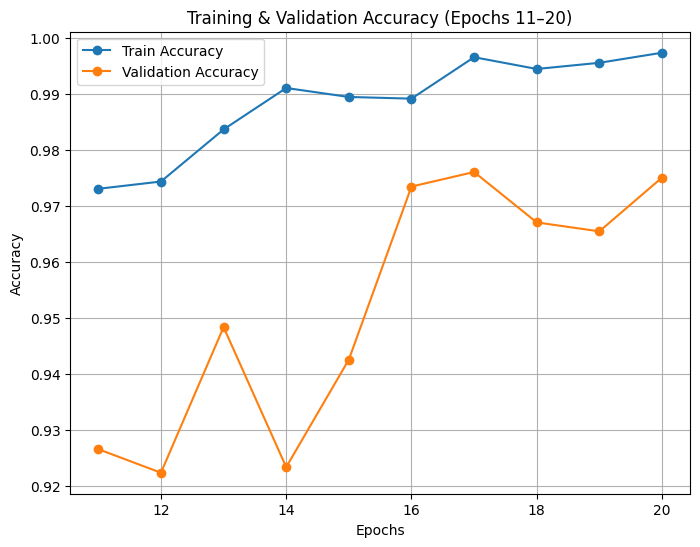

In [38]:
import matplotlib.pyplot as plt


train_losses = [0.0791, 0.0698, 0.0527, 0.0262, 0.0327, 0.0331, 0.0118, 0.0187, 0.0145, 0.0088]
val_losses   = [0.2442, 0.2398, 0.1633, 0.2923, 0.1753, 0.0953, 0.1003, 0.1129, 0.1201, 0.1058]
train_acc    = [0.9730, 0.9743, 0.9836, 0.9910, 0.9894, 0.9891, 0.9965, 0.9944, 0.9955, 0.9973]
val_acc      = [0.9265, 0.9223, 0.9483, 0.9233, 0.9425, 0.9734, 0.9760, 0.9670, 0.9654, 0.9750]


epochs = list(range(11, 21))

# ---- Plot Loss ----
plt.figure(figsize=(8,6))
plt.plot(epochs, train_losses, label="Train Loss", marker='o')
plt.plot(epochs, val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (Epochs 11–20)")
plt.legend()
plt.grid(True)
plt.show()

# ---- Plot Accuracy ----
plt.figure(figsize=(8,6))
plt.plot(epochs, train_acc, label="Train Accuracy", marker='o')
plt.plot(epochs, val_acc, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy (Epochs 11–20)")
plt.legend()
plt.grid(True)
plt.show()
